# CROP YIELD PREDICTION - ML PROJECT

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 80)
print("CROP YIELD PREDICTION - COMPREHENSIVE ML PROJECT")
print("=" * 80)


CROP YIELD PREDICTION - COMPREHENSIVE ML PROJECT


###  1. DATA LOADING AND INITIAL EXPLORATION

In [5]:


df = pd.read_csv('yield.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Sample rows
print("\nSample Data:")
print(df.head())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Check for missing values
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing)


Dataset Shape: (56717, 12)

Columns: ['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']

Sample Data:
  Domain Code Domain  Area Code         Area  Element Code Element  Item Code  \
0          QC  Crops          2  Afghanistan          5419   Yield         56   
1          QC  Crops          2  Afghanistan          5419   Yield         56   
2          QC  Crops          2  Afghanistan          5419   Yield         56   
3          QC  Crops          2  Afghanistan          5419   Yield         56   
4          QC  Crops          2  Afghanistan          5419   Yield         56   

    Item  Year Code  Year   Unit  Value  
0  Maize       1961  1961  hg/ha  14000  
1  Maize       1962  1962  hg/ha  14000  
2  Maize       1963  1963  hg/ha  14260  
3  Maize       1964  1964  hg/ha  14257  
4  Maize       1965  1965  hg/ha  14400  

Summary Statistics:
          Area Code  Element Code     Item Code     Year

### 2. EXPLORATORY DATA ANALYSIS (EDA)

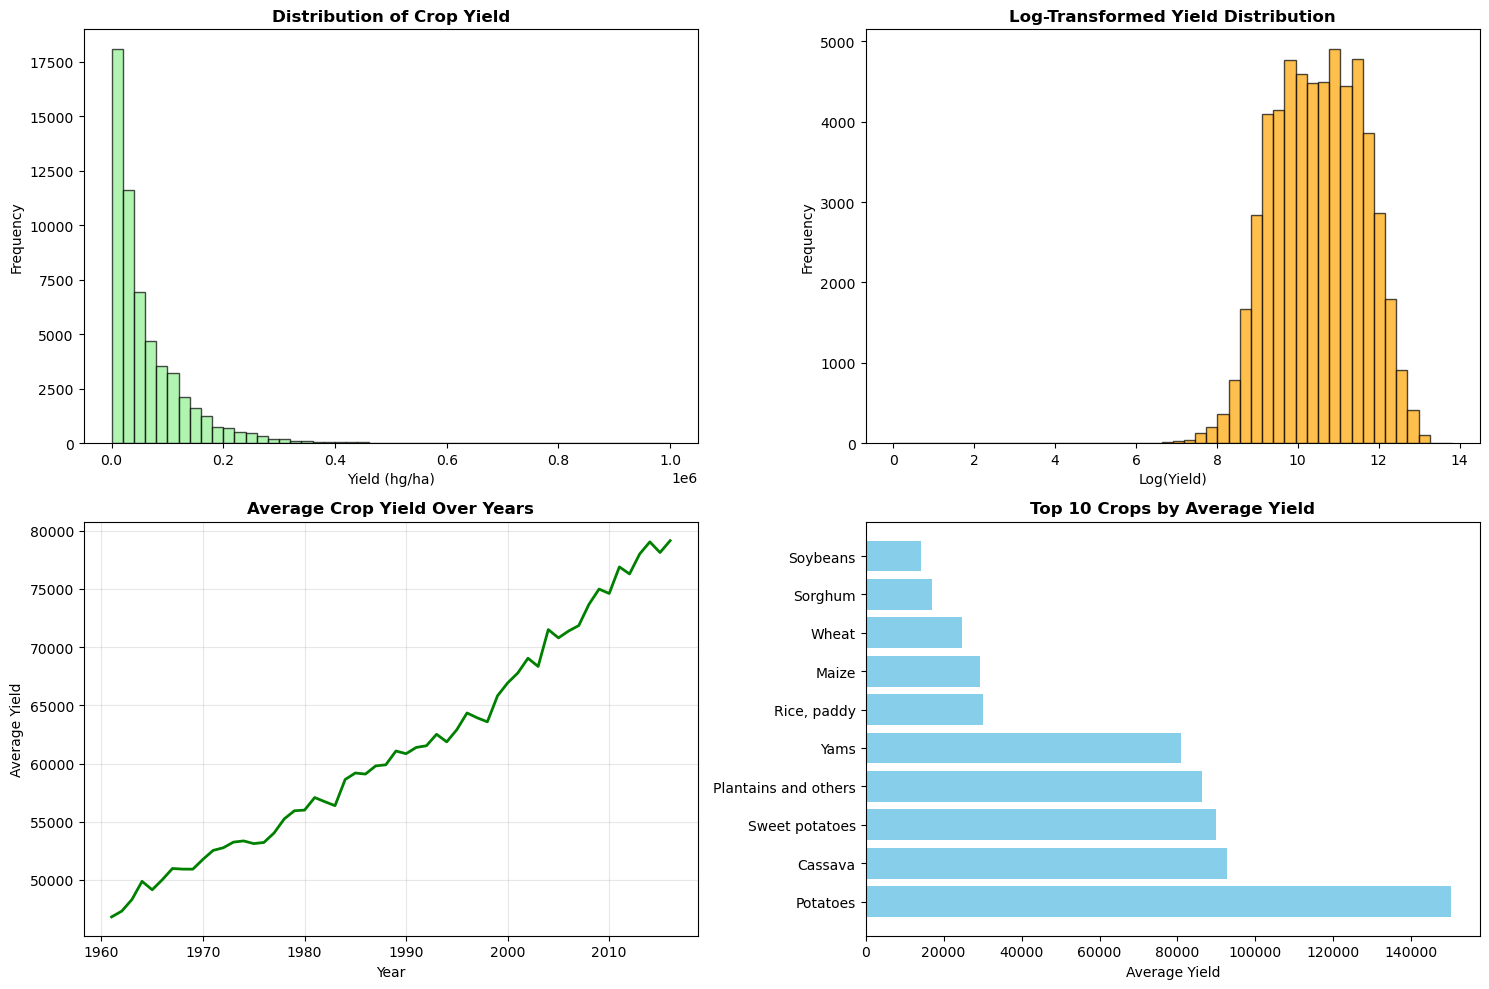

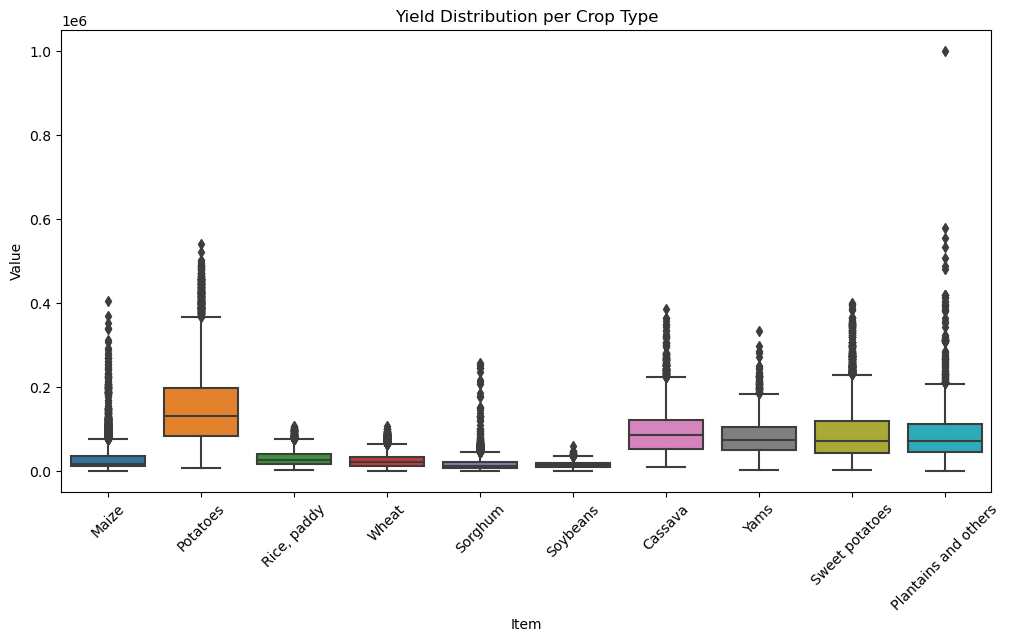

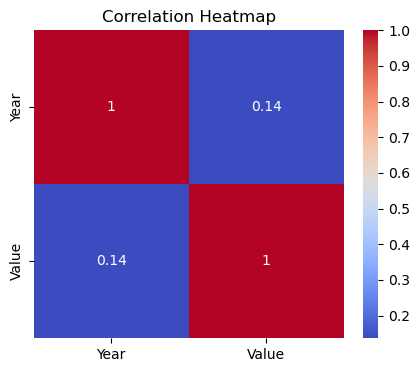

Outlier Analysis (IQR Method):
Number of outliers: 3169 (5.59%)


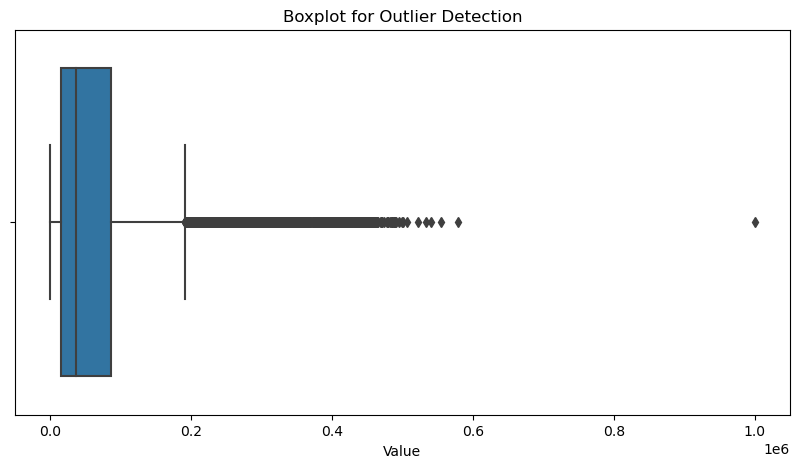

In [6]:

# -------------------------------
# 1. Distribution Analysis
# -------------------------------

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1.1 Yield Distribution
axes[0, 0].hist(df['Value'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 0].set_title('Distribution of Crop Yield', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Yield (hg/ha)')
axes[0, 0].set_ylabel('Frequency')

# 1.2 Log-transformed Yield Distribution
axes[0, 1].hist(np.log1p(df['Value']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Log-Transformed Yield Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Log(Yield)')
axes[0, 1].set_ylabel('Frequency')

# 1.3 Yield over Years (average yield per year)
yearly_yield = df.groupby('Year')['Value'].mean()
axes[1, 0].plot(yearly_yield.index, yearly_yield.values, color='green', linewidth=2)
axes[1, 0].set_title('Average Crop Yield Over Years', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Yield')
axes[1, 0].grid(True, alpha=0.3)

# 1.4 Top 10 Crops by Average Yield
top_crops = df.groupby('Item')['Value'].mean().nlargest(10)
axes[1, 1].barh(top_crops.index, top_crops.values, color='skyblue')
axes[1, 1].set_title('Top 10 Crops by Average Yield', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Yield')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------
# 2. Boxplot per Crop
# -------------------------------
plt.figure(figsize=(12,6))
sns.boxplot(x='Item', y='Value', data=df)
plt.xticks(rotation=45)
plt.title('Yield Distribution per Crop Type')
plt.show()

# -------------------------------
# 3. Correlation Heatmap
# -------------------------------
numerical_cols = ['Year', 'Value']
plt.figure(figsize=(5,4))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# -------------------------------
# 4. Outlier Detection (IQR method)
# -------------------------------
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Value'] < Q1 - 1.5*IQR) | (df['Value'] > Q3 + 1.5*IQR)]

print(f"Outlier Analysis (IQR Method):")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Optional: visualize outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Value'])
plt.title('Boxplot for Outlier Detection')
plt.show()


###  3. DATA PREPROCESSING & FEATURE ENGINEERING

In [7]:

# 3.1 Handle outliers (capping extreme values)
df['Value'] = df['Value'].clip(lower=df['Value'].quantile(0.01), 
                                  upper=df['Value'].quantile(0.99))

# 3.2 Log transformation of target variable
df['Value_log'] = np.log1p(df['Value'])

# 3.3 Feature Engineering
print("\nCreating engineered features...")

# Temporal features
df['Year_Normalized'] = (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min())
df['Year_Squared'] = df['Year'] ** 2
df['Year_Cubic'] = df['Year'] ** 3

# Statistical features by crop
crop_stats = df.groupby('Item')['Value'].agg(['mean', 'std', 'median', 'min', 'max'])
crop_stats.columns = ['Crop_Avg_Yield', 'Crop_Std_Yield', 'Crop_Median_Yield', 
                      'Crop_Min_Yield', 'Crop_Max_Yield']
df = df.merge(crop_stats, left_on='Item', right_index=True)

# Statistical features by region
region_stats = df.groupby('Area')['Value'].agg(['mean', 'std', 'median'])
region_stats.columns = ['Region_Avg_Yield', 'Region_Std_Yield', 'Region_Median_Yield']
df = df.merge(region_stats, left_on='Area', right_index=True)

# Interaction features
df['Crop_Region_Interaction'] = df['Crop_Avg_Yield'] * df['Region_Avg_Yield']
df['Year_Crop_Interaction'] = df['Year_Normalized'] * df['Crop_Avg_Yield']

# Variance features
df['Crop_Coefficient_Variation'] = df['Crop_Std_Yield'] / (df['Crop_Avg_Yield'] + 1e-5)

print(f"Total features after engineering: {df.shape[1]}")

# 3.4 Encode categorical variables
print("\nEncoding categorical variables...")
df_encoded = pd.get_dummies(df, columns=['Area', 'Item'], drop_first=True)

# 3.5 Prepare features and target
X = df_encoded.drop(['Value', 'Value_log', 'Domain Code', 'Domain', 
                     'Element Code', 'Element', 'Item Code', 
                     'Year Code', 'Unit'], axis=1, errors='ignore')
y = df_encoded['Value_log']

print(f"Final feature set shape: {X.shape}")
print(f"Feature names: {X.columns.tolist()[:10]}... (showing first 10)")

# 3.6 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# 3.7 Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Creating engineered features...
Total features after engineering: 27

Encoding categorical variables...
Final feature set shape: (56717, 236)
Feature names: ['Area Code', 'Year', 'Year_Normalized', 'Year_Squared', 'Year_Cubic', 'Crop_Avg_Yield', 'Crop_Std_Yield', 'Crop_Median_Yield', 'Crop_Min_Yield', 'Crop_Max_Yield']... (showing first 10)

Training set: (45373, 236)
Test set: (11344, 236)


### 4. MODEL DEVELOPMENT & OPTIMIZATION

In [8]:
# 4.1 Linear Regression (Baseline)
print("\n4.1 Training Linear Regression (Baseline)...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 4.2 Random Forest with GridSearch
print("\n4.2 Training Random Forest with Hyperparameter Tuning...")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, 25],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_model = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=3, scoring='r2', 
                       verbose=1, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best RF parameters: {rf_grid.best_params_}")
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)

# 4.3 Artificial Neural Network with optimization
print("\n4.4 Training Optimized ANN...")
ann_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_dim=X_train_scaled.shape[1],
                 kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

ann_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, 
                                                restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                                               patience=5, min_lr=1e-7)

history = ann_model.fit(X_train_scaled, y_train,
                        epochs=100,
                        batch_size=64,
                        validation_split=0.15,
                        callbacks=[early_stopping, reduce_lr],
                        verbose=0)

y_pred_ann = ann_model.predict(X_test_scaled, verbose=0).flatten()


4.1 Training Linear Regression (Baseline)...

4.2 Training Random Forest with Hyperparameter Tuning...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF parameters: {'max_depth': 25, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

4.4 Training Optimized ANN...


### 5. MODEL EVALUATION

In [9]:

def evaluate_model(y_true, y_pred, model_name):
    """Comprehensive model evaluation"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert back from log scale for interpretability
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    rmse_original = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    
    print(f"\n{model_name}:")
    print(f"  RMSE (log scale): {rmse:.4f}")
    print(f"  RMSE (original scale): {rmse_original:.2f} hg/ha")
    print(f"  MAE (log scale): {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'RMSE_orig': rmse_original}

metrics = {}
metrics['Linear Regression'] = evaluate_model(y_test, y_pred_lr, 'Linear Regression')
metrics['Random Forest'] = evaluate_model(y_test, y_pred_rf, 'Random Forest')
metrics['ANN'] = evaluate_model(y_test, y_pred_ann, 'Artificial Neural Network')



Linear Regression:
  RMSE (log scale): 0.5084
  RMSE (original scale): 34430.40 hg/ha
  MAE (log scale): 0.3836
  R² Score: 0.7726

Random Forest:
  RMSE (log scale): 0.1781
  RMSE (original scale): 11567.28 hg/ha
  MAE (log scale): 0.1075
  R² Score: 0.9721

Artificial Neural Network:
  RMSE (log scale): 0.2778
  RMSE (original scale): 32319.30 hg/ha
  MAE (log scale): 0.2008
  R² Score: 0.9321


### 6. VISUALIZATION & RESULTS

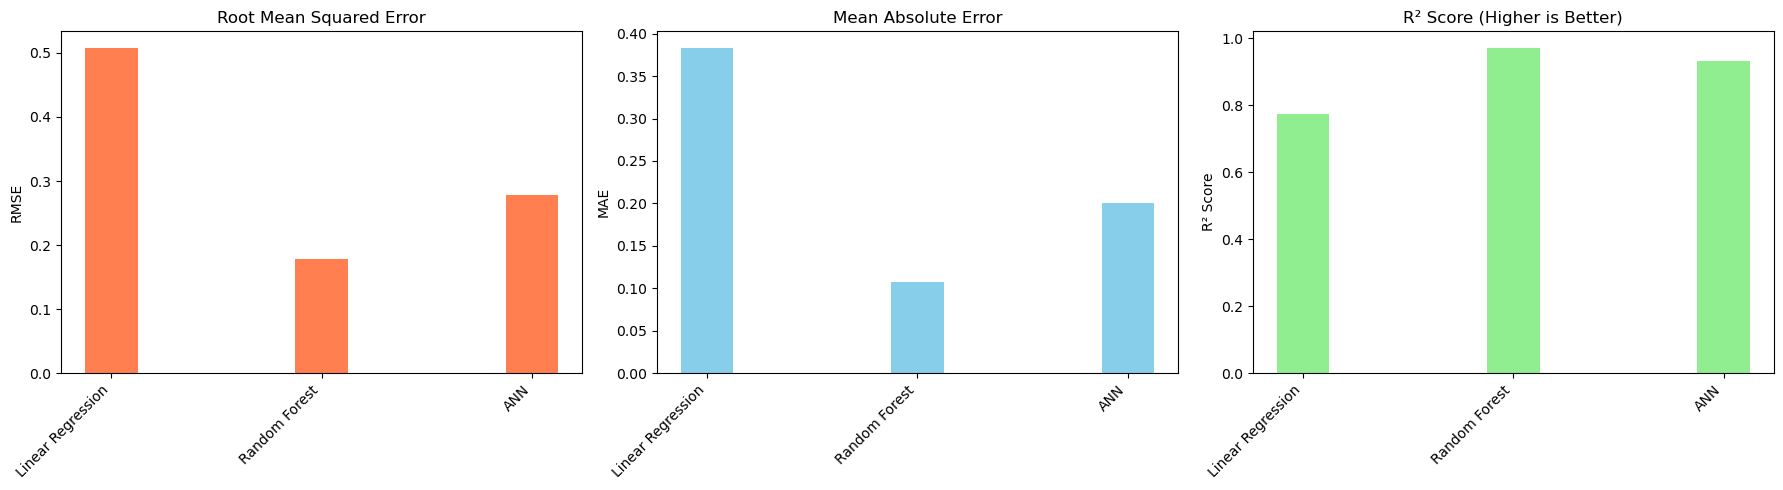

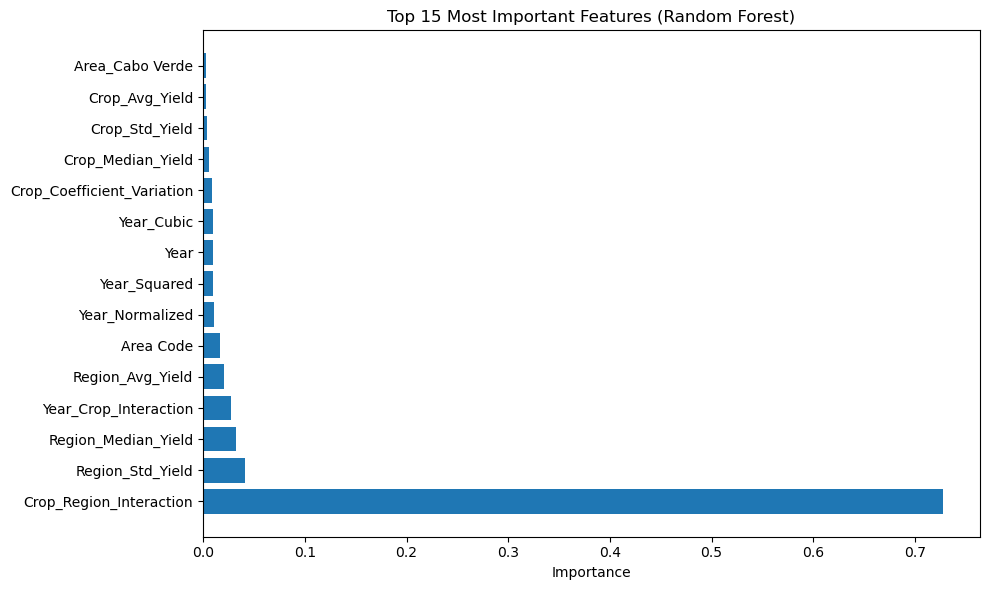

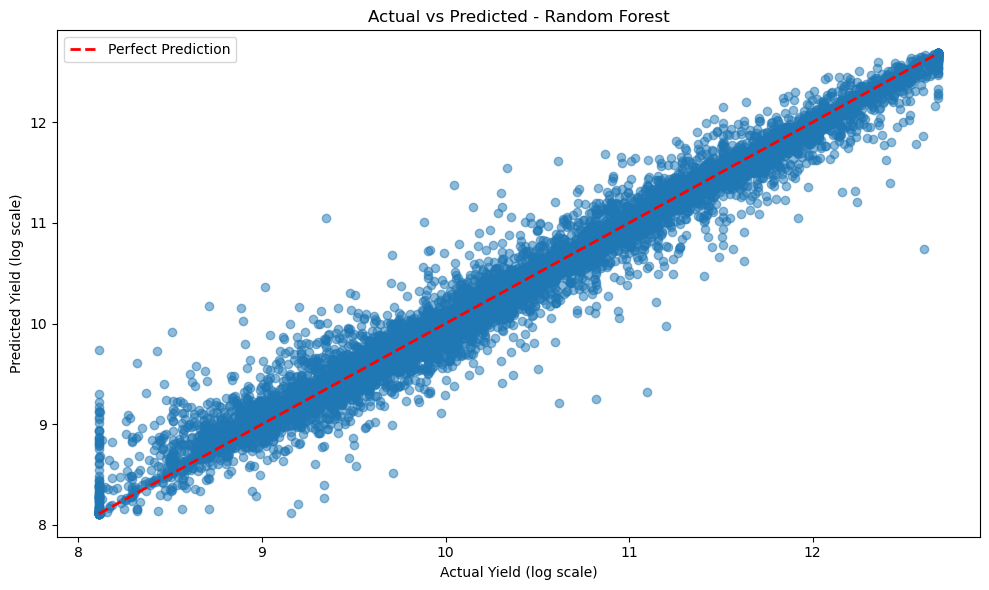

In [11]:

# 6.1 Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = list(metrics.keys())
rmse_vals = [metrics[m]['RMSE'] for m in models]
mae_vals = [metrics[m]['MAE'] for m in models]
r2_vals = [metrics[m]['R2'] for m in models]

x = np.arange(len(models))
width = 0.25

axes[0].bar(x, rmse_vals, width, label='RMSE', color='coral')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Root Mean Squared Error')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')

axes[1].bar(x, mae_vals, width, label='MAE', color='skyblue')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')

axes[2].bar(x, r2_vals, width, label='R²', color='lightgreen')
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.2 Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.3 Prediction vs Actual (Best Model)
best_model_name = max(metrics, key=lambda x: metrics[x]['R2'])
if best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
else:
    y_pred_best = y_pred_ann

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yield (log scale)')
plt.ylabel('Predicted Yield (log scale)')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()


### 7. FINAL SUMMARY

In [13]:

print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"\nBest Performing Model: {best_model_name}")
print(f"R² Score: {metrics[best_model_name]['R2']:.4f}")
print(f"RMSE: {metrics[best_model_name]['RMSE']:.4f}")

print("\n" + "=" * 80)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 80)


FINAL SUMMARY

Best Performing Model: Random Forest
R² Score: 0.9721
RMSE: 0.1781

PROJECT COMPLETED SUCCESSFULLY
